In [53]:
%matplotlib widget

In [54]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u

In [55]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_29_16.174.fits") #image
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits") #spectrum
image_data = hdul[0].data
image_data_2 = hdul2[0].data
image_error_2 = hdul2[1].data

In [56]:
image_cut = image_data[58:158, 1050:1200]
image_cut_2 = image_data_2[55:155, 0:1890] 
image_error_cut_2 = image_error_2[55:155, 0:1890]

In [57]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, params1, params2, params3, params4):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def sersic_1d_convolved(x, sigma, params):
    """ Sérsic convoluto con PSF gaussiana """
    I_e, r_e, n, x_0 = params
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, params)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

In [58]:
z = 0.0238
l_HA = 6563 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/PSF/Real_seeing_Mrk544.txt")
sigmas = seeing / 2.35

wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut_2[:, mask_HA]
image_error_HA = image_error_cut_2[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

 [astropy.io.fits.verify]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


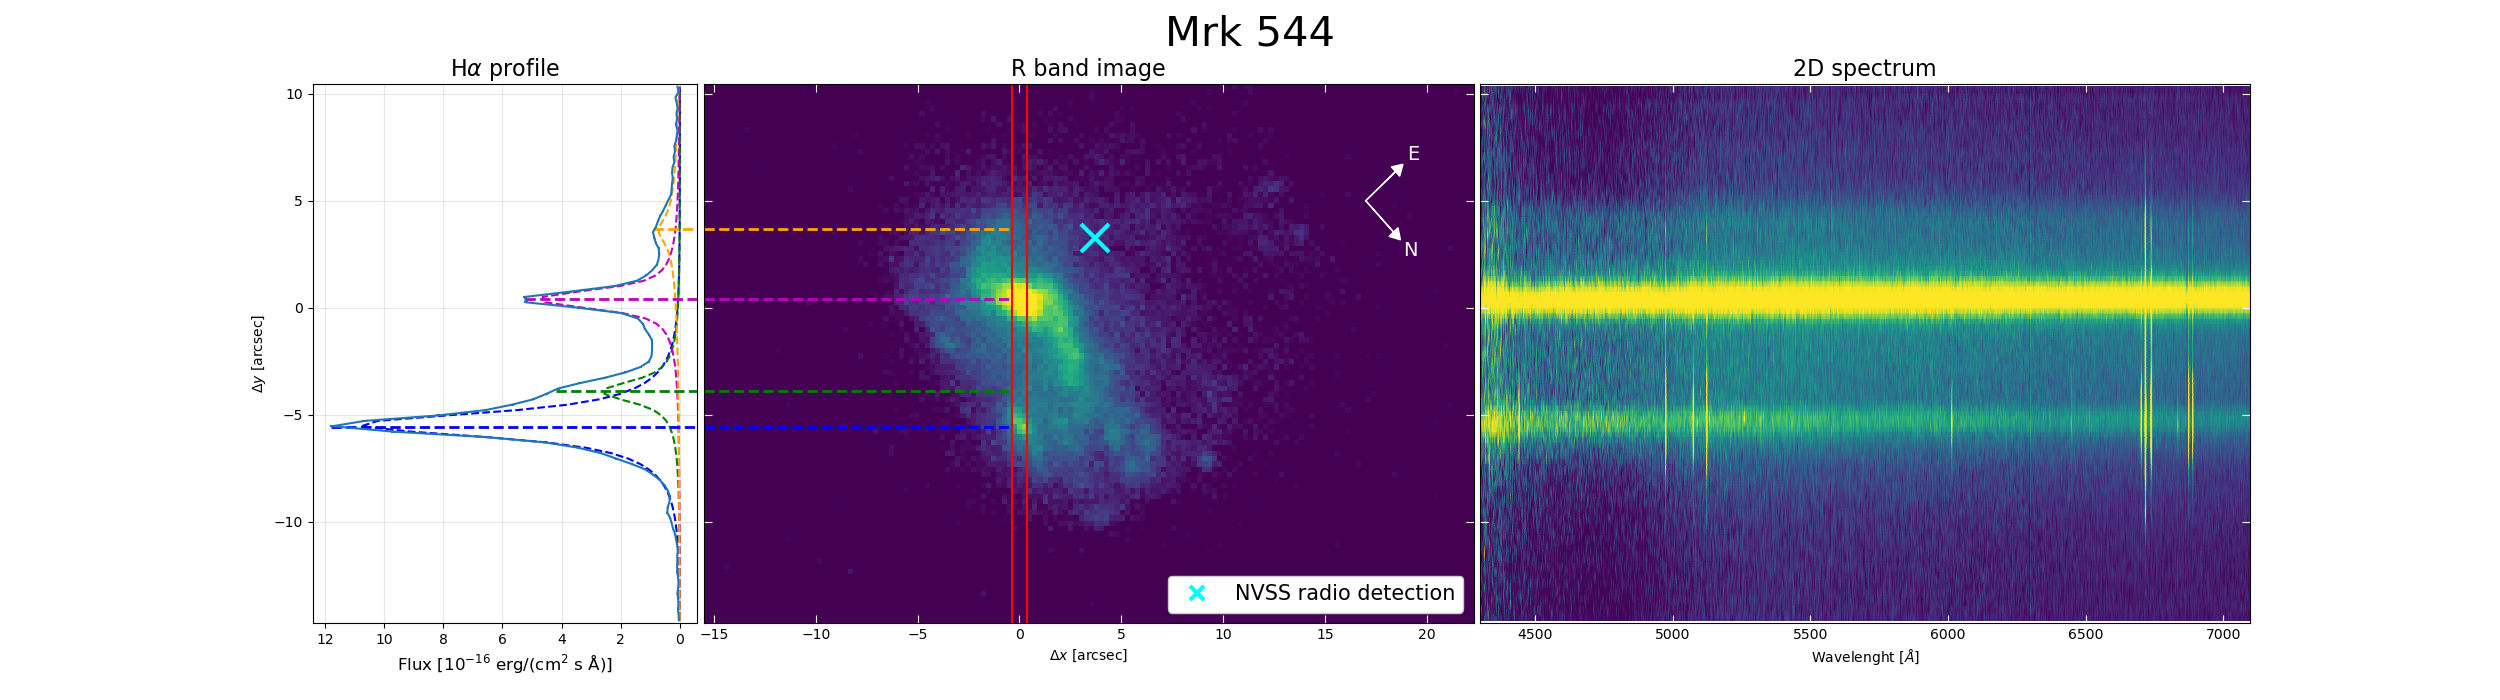

In [59]:
arcsec_x = np.arange(-61*0.252, 89*0.252, 0.252)
arcsec_y = np.arange(-58*0.252, 42*0.252, 0.252)
#x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)
#x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)
J, N = image_cut.shape
x = np.arange(0, N, 1)
y = np.arange(0, J, 1)

x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)

J_2, N_2 = image_cut_2.shape
x_2 = np.arange(0, N_2, 1)
y_2 = np.arange(0, J_2, 1)

x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)

y_fit = model_convolved(x_axes, sigmas[0], fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])

fig, ax = plt.subplots(1, 3, figsize=(25, 7), 
                      gridspec_kw={'width_ratios': [1, 2, 2], 'wspace': 0.01},
                      sharey=True)
fig.suptitle('Mrk 544', fontsize=30)


ax[0].errorbar(radial_profile_HA, arcsec_y, xerr = radial_profile_error_HA, label='Data')

colors = ['b', 'g', 'm', 'orange'] 
components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigmas[0], np.array(fit[comp_name]))
        ax[0].plot(y_comp, arcsec_y, '--', color=color,  
                  label=f'Sérsic {i+1}')
    
ax[0].set_xlabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
#ax[0].legend(loc='upper right', fontsize=13)
ax[0].grid(True, alpha=0.3)
ax[0].invert_xaxis()
xlim = ax[0].get_xlim()
ax[0].hlines(y=-5.56, xmin=11.78, xmax = xlim[1],  color='blue', linewidth=2, linestyle = '--')
ax[0].hlines(y=-3.91, xmin=4.18, xmax = xlim[1],  color='g', linewidth=2, linestyle = '--')
ax[0].hlines(y=0.41, xmin=5.23, xmax = xlim[1],  color='m', linewidth=2, linestyle = '--')
ax[0].hlines(y=3.69, xmin=0.91, xmax = xlim[1],  color='orange', linewidth=2, linestyle = '--')
ax[0].set_xlim(xlim[0], xlim[1])

ax[1].pcolormesh(x_grid, y_grid, np.log10(image_cut), shading='nearest', vmin=np.log10(3500), vmax=np.log10(5800), cmap = 'viridis') #hot: 2500, 6000

# Leggi il WCS dall'header dell'immagine
wcs = WCS(hdul[0].header)

# Calcola l'orientamento del Nord
ny, nx = image_cut.shape
x_center, y_center = nx / 2, ny / 2

# Converti le coordinate pixel in coordinate world
# Nota: devi usare le coordinate ORIGINALI prima del taglio
x_orig_center = 1050 + x_center
y_orig_center = 58 + y_center

coord_center = wcs.pixel_to_world(x_orig_center, y_orig_center)
coord_up = wcs.pixel_to_world(x_orig_center, y_orig_center + 50)

# Calcola l'angolo di posizione del nord
pa = coord_center.position_angle(coord_up).deg

# Posizione delle frecce nell'immagine tagliata (angolo in alto a destra)
# In coordinate arcsec
x_arrow = 17  # arcsec dalla posizione di riferimento
y_arrow = 5   # arcsec dalla posizione di riferimento
arrow_len = 2  # arcsec

# Converti l'angolo in radianti e calcola i componenti delle frecce
# Freccia Nord
dx_n = arrow_len * np.sin(np.radians(pa))
dy_n = arrow_len * np.cos(np.radians(pa))

ax[1].arrow(x_arrow, y_arrow, dx_n, dy_n,
            head_width=0.6, head_length=0.5,
            fc='white', ec='white', linewidth=1)
ax[1].text(x_arrow + dx_n * 1.6, y_arrow + dy_n * 1.6, 'N',
           ha='center', va='center', color='white',
           fontsize=14) #, fontweight='bold')

# Freccia Est (perpendicolare al nord, -90°)
dx_e = arrow_len * np.sin(np.radians(pa - 90))
dy_e = arrow_len * np.cos(np.radians(pa - 90))

ax[1].arrow(x_arrow, y_arrow, dx_e, dy_e,
            head_width=0.6, head_length=0.5,
            fc='white', ec='white', linewidth=1)
ax[1].text(x_arrow + dx_e * 1.6, y_arrow + dy_e * 1.6, 'E',
           ha='center', va='center', color='white',
           fontsize=14) #, fontweight='bold')

# Coordinate in pixel dell'immagine ORIGINALE (2048x1034)
x_pixel_orig = 1125.7979  # esempio
y_pixel_orig = 128.86322   # esempio

# Converti in coordinate del taglio
x_cut = x_pixel_orig - 1050  # sottrai l'offset x del taglio
y_cut = y_pixel_orig - 58    # sottrai l'offset y del taglio

# Converti in arcsec
x_arcsec = arcsec_x[0] + x_cut * 0.252
y_arcsec = arcsec_y[0] + y_cut * 0.252

# Plotta
ax[1].plot(x_arcsec, y_arcsec, 'x', color='cyan', 
           markersize=20, markeredgewidth=3, label='NVSS radio detection')

ax[1].set_xlabel(r'$\Delta x$ [arcsec]')
ax[0].set_ylabel(r'$\Delta y$ [arcsec]')
ax[1].axvline(-0.35, color='red')
ax[1].axvline(0.35, color='red')
ax[1].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)
#ax[1].grid(True, alpha=0.3, color = 'white')
xlim = ax[1].get_xlim()
ax[1].hlines(y=-5.56, xmin =xlim[0],  xmax=-0.5, color='blue', linewidth=2, linestyle = '--')
ax[1].hlines(y=-3.91, xmin =xlim[0],  xmax=-0.5, color='g', linewidth=2, linestyle = '--')
ax[1].hlines(y=0.41, xmin =xlim[0],  xmax=-0.5, color='m', linewidth=2, linestyle = '--')
ax[1].hlines(y=3.69, xmin =xlim[0],  xmax=-0.5, color='orange', linewidth=2, linestyle = '--')
ax[1].set_xlim(xlim[0], xlim[1])

ax[2].pcolormesh(x_grid_2, y_grid_2, image_cut_2, shading='gouraud', vmin=np.percentile(image_cut_2, 5), vmax=np.percentile(image_cut_2, 95)) #altre opzioni
ax[2].set_xlabel(r'Wavelenght [$\AA$]')
ax[2].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)

ax[0].set_title(r'H$\alpha$ profile', fontsize=16)
ax[1].set_title('R band image', fontsize=16)
ax[2].set_title('2D spectrum', fontsize=16)
ax[1].legend(markerscale = 0.5, loc = 'lower right', framealpha =1, fontsize = 15)
plt.subplots_adjust(wspace=0.01)

fig.savefig("Mrk544_all_lines.png", bbox_inches='tight')

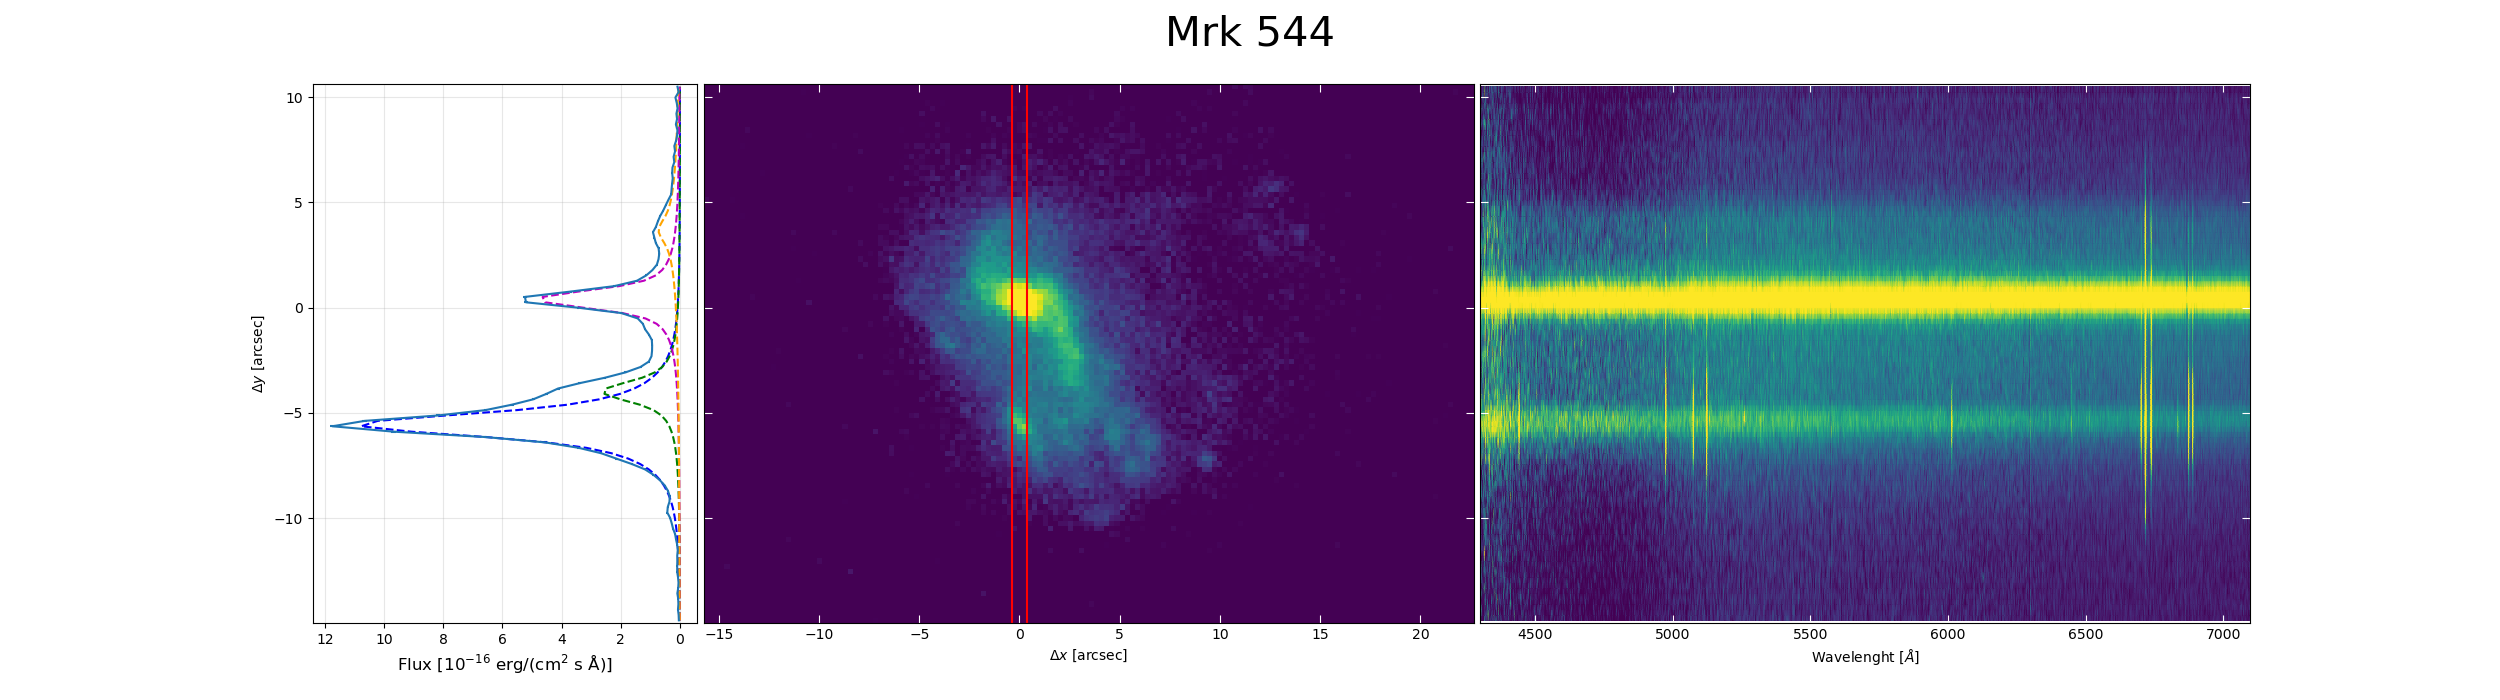

In [60]:
arcsec_x = np.arange(-61*0.256, 89*0.256, 0.256)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)
#x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)
#x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)
J, N = image_cut.shape
x = np.arange(0, N, 1)
y = np.arange(0, J, 1)

x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)

J_2, N_2 = image_cut_2.shape
x_2 = np.arange(0, N_2, 1)
y_2 = np.arange(0, J_2, 1)

x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)

y_fit = model_convolved(x_axes, sigmas[0], fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])

fig, ax = plt.subplots(1, 3, figsize=(25, 7), 
                      gridspec_kw={'width_ratios': [1, 2, 2], 'wspace': 0.01},
                      sharey=True)
fig.suptitle('Mrk 544', fontsize=30)

ax[0].errorbar(radial_profile_HA, arcsec_y, xerr = radial_profile_error_HA, label='Data')

colors = ['b', 'g', 'm', 'orange'] 
components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigmas[0], np.array(fit[comp_name]))
        ax[0].plot(y_comp, arcsec_y, '--', color=color,  
                  label=f'Sérsic {i+1}')
    
ax[0].set_xlabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
#ax[0].legend(loc='upper right', fontsize=13)
ax[0].grid(True, alpha=0.3)
ax[0].invert_xaxis()

ax[1].pcolormesh(x_grid, y_grid, np.log10(image_cut), shading='nearest', vmin=np.log10(3500), vmax=np.log10(5800), cmap = 'viridis') #hot: 2500, 6000
ax[1].set_xlabel(r'$\Delta x$ [arcsec]')
ax[0].set_ylabel(r'$\Delta y$ [arcsec]')
ax[1].axvline(-0.35, color='red')
ax[1].axvline(0.35, color='red')
ax[1].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)
#ax[1].grid(True, alpha=0.3, color = 'white')

ax[2].pcolormesh(x_grid_2, y_grid_2, image_cut_2, shading='gouraud', vmin=np.percentile(image_cut_2, 5), vmax=np.percentile(image_cut_2, 95)) #altre opzioni
ax[2].set_xlabel(r'Wavelenght [$\AA$]')
ax[2].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)
plt.subplots_adjust(wspace=0.01)

fig.savefig("Mrk544_all.png")

In [61]:
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 1.1979 -1.50269 
CRPIX : 1023.0 118.1 
CD1_1 CD1_2  : 5.118167e-05 4.772768e-05 
CD2_1 CD2_2  : 4.772768e-05 -5.118167e-05 
NAXIS : 2048  1034

In [62]:
hdul[0].header

SIMPLE  =                    T          / Standard FITS format (NOST-100.0)     
BITPIX  =                   16          / # of bits storing pix values          
NAXIS   =                    2          / # of axes in frame                    
NAXIS1  =                 2048          / # pixels/axis                         
NAXIS2  =                 1034          / # pixels/axis                         
ORIGIN  = 'ESO     '                    / European Southern Observatory         
DATE    = '2021-08-21T05:29:29.345'     / UT date when this file was written    
MJD-OBS =       59447.22865941          / MJD start (2021-08-21T05:29:16.173)   
DATE-OBS= '2021-08-21T05:29:16.173'     / Date of observation                   
EXPTIME =               9.9988          / Total integration time                
CRVAL1  =              1.19790          / value of ref pixel                    
CRPIX1  =               1023.0          / Ref pixel in x-axis                   
CTYPE1  = 'RA---TAN'        